# Part II-A: Feed-Forward Neural Network (FFNN) for Surface Crack Classification

## Overview
This notebook implements a Feed-Forward Neural Network (FFNN) for classifying cracked vs non-cracked surfaces. We will:
1. Load and prepare the data
2. Define the FFNN model architecture
3. Explore different hyperparameters systematically
4. Train and evaluate the model

## Hyperparameters to Explore
- **Batch size**: 16, 32, 64
- **Number of layers**: 2, 3, 4 hidden layers
- **Dropout rate**: 0.0, 0.3, 0.5
- **Optimizer**: SGD, Adam, RMSProp
- **L2 Regularization (weight decay)**: 0.0, 1e-4, 1e-3
- **Learning rate**: 0.1, 0.01, 0.001
- **Learning rate scheduler**: StepLR, ReduceLROnPlateau

### Import Libraries
Import PyTorch, data utilities, and visualization libraries needed for this notebook.

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import pandas as pd
import time
import copy
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

### Configure Device
Check if GPU is available for faster training, otherwise use CPU.

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
torch.backends.cudnn.benchmark = True
print("CUDNN Benchmark Enabled (Eager Mode Optimized)")
torch.backends.cudnn.benchmark = True
print("PyTorch Eager Mode: Active (CUDNN benchmark enabled)")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
CUDNN Benchmark Enabled (Eager Mode Optimized)
PyTorch Eager Mode: Active (CUDNN benchmark enabled)
GPU: NVIDIA GeForce GTX 1060 3GB


### Define Custom Dataset Class
Create a PyTorch Dataset to load images from the Cracked and Non Cracked folders.

In [3]:
class SurfaceCrackDataset(Dataset):
    def __init__(self, cracked_dir, non_cracked_dir, transform=None, max_samples=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        cracked_files = sorted(os.listdir(cracked_dir))
        if max_samples:
            cracked_files = cracked_files[:max_samples]
        for fname in cracked_files:
            self.image_paths.append(os.path.join(cracked_dir, fname))
            self.labels.append(1)
        
        non_cracked_files = sorted(os.listdir(non_cracked_dir))
        if max_samples:
            non_cracked_files = non_cracked_files[:max_samples]
        for fname in non_cracked_files:
            self.image_paths.append(os.path.join(non_cracked_dir, fname))
            self.labels.append(0)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)

### Set Up Data Transforms and Loaders
Define image preprocessing (resize, normalize) and create train/test DataLoaders.

In [4]:
CRACKED_DIR = 'Cracked'
NON_CRACKED_DIR = 'Non Cracked'
IMAGE_SIZE = 227

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = SurfaceCrackDataset(CRACKED_DIR, NON_CRACKED_DIR, transform=train_transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], 
                                            generator=torch.Generator().manual_seed(42))
test_dataset.dataset.transform = test_transform

print(f"Training samples: {train_size}")
print(f"Testing samples: {test_size}")

Training samples: 76873
Testing samples: 19219


25% Tuning Subset

In [5]:
# ========== NEW CELL: 25% Tuning Data Subset ==========
TUNE_FRACTION = 0.25
generator = torch.Generator().manual_seed(42)  # Reproducible splits
# 25% of original training data (80% of full data → 20% of full data)
tune_train_size = int(TUNE_FRACTION * len(train_dataset))
train_indices = torch.randperm(len(train_dataset), generator=generator).tolist()[:tune_train_size]
tuned_train_dataset = torch.utils.data.Subset(train_dataset, train_indices)
# 25% of original test data (20% of full data → 5% of full data)
tune_test_size = int(TUNE_FRACTION * len(test_dataset))
test_indices = torch.randperm(len(test_dataset), generator=generator).tolist()[:tune_test_size]
tuned_test_dataset = torch.utils.data.Subset(test_dataset, test_indices)
# Default tuning DataLoaders (batch size 32, overridden only in Batch Size experiment)
TUNE_BATCH_SIZE = 32
tuned_train_loader = DataLoader(tuned_train_dataset, batch_size=TUNE_BATCH_SIZE, shuffle=True, num_workers=0)
tuned_test_loader = DataLoader(tuned_test_dataset, batch_size=TUNE_BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Tuning Data Sizes:")
print(f"  Train: {len(tuned_train_dataset)} samples")
print(f"  Test: {len(tuned_test_dataset)} samples")
print(f"Total Tuning Data: {len(tuned_train_dataset) + len(tuned_test_dataset)} samples")
# ========== END NEW CELL ==========

Tuning Data Sizes:
  Train: 19218 samples
  Test: 4804 samples
Total Tuning Data: 24022 samples


### Define FFNN Model
Build a flexible Feed-Forward Neural Network where we can configure the number of hidden layers, hidden size, dropout rate, and input size (flattened image).

In [6]:
class FFNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes=2, dropout_rate=0.0):
        super(FFNN, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

input_size = 3 * IMAGE_SIZE * IMAGE_SIZE
print(f"Input size (flattened image): {input_size}")

Input size (flattened image): 154587


### Define Training Function
Create a training function that handles one epoch of training, tracking loss and accuracy.

In [7]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, verbose=False):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    loader = tqdm(train_loader, desc='Training', leave=False) if verbose else train_loader
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if verbose:
            loader.set_postfix({'loss': f'{loss.item():.4f}', 'avg_loss': f'{running_loss/total:.4f}', 'acc': f'{correct/total:.4f}'})
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

### Define Evaluation Function
Create an evaluation function that tests the model on a dataset and returns loss, accuracy, and per-class metrics.

In [8]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    class_correct = [0, 0]
    class_total = [0, 0]
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            for i in range(labels.size(0)):
                label = labels[i].item()
                class_total[label] += 1
                class_correct[label] += predicted[i].eq(label).item()
    
    avg_loss = running_loss / total
    accuracy = correct / total
    
    class_accuracies = [c / t if t > 0 else 0 for c, t in zip(class_correct, class_total)]
    
    return avg_loss, accuracy, class_accuracies

### Define Full Training Loop
Combine training and evaluation into a complete training loop that supports learning rate scheduling and saves the best model.

In [9]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler, 
                num_epochs, device, model_name='ffnn', verbose=False):
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
        'test_acc_cracked': [], 'test_acc_non_cracked': []
    }
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(num_epochs):
        print(f'Epoch [{epoch+1}/{num_epochs}]') if verbose else None
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, verbose=verbose)
        test_loss, test_acc, test_class_acc = evaluate(model, test_loader, criterion, device)
        
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_loss)
            else:
                scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['test_acc_cracked'].append(test_class_acc[1])
        history['test_acc_non_cracked'].append(test_class_acc[0])
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1}/{num_epochs}] LR: {current_lr:.6f} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}')
    
    model.load_state_dict(best_model_wts)
    return model, history, best_acc

### Helper Function: Plot Training History
Visualize training and test loss/accuracy curves to analyze model learning behavior.

In [10]:
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['test_loss'], label='Test Loss', marker='s')
    axes[0].set_title('Loss Over Epochs', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
    axes[1].plot(history['test_acc'], label='Test Accuracy', marker='s')
    axes[1].plot(history['test_acc_cracked'], label='Test Acc (Cracked)', marker='^', linestyle='--')
    axes[1].plot(history['test_acc_non_cracked'], label='Test Acc (Non-Cracked)', marker='v', linestyle='--')
    axes[1].set_title('Accuracy Over Epochs', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Experiment 1: Baseline Configuration
Start with a reasonable baseline: 3 hidden layers, 256 units each, no dropout, Adam optimizer, lr=0.001, 15 epochs. This gives us a reference point for comparing other configurations.

In [11]:
# Diagnostic: Check variable types
print(f"train_dataset type: {type(train_dataset)}")  # Should be Subset
print(f"test_dataset type: {type(test_dataset)}")      # Should be Subset
print(f"tuned_train_dataset type: {type(tuned_train_dataset)}")  # Should be Subset
print(f"tuned_test_dataset type: {type(tuned_test_dataset)}")    # Should be Subset
print(f"tuned_train_loader type: {type(tuned_train_loader)}")  # Should be DataLoader
print(f"tuned_test_loader type: {type(tuned_test_loader)}")    # Should be DataLoader

train_dataset type: <class 'torch.utils.data.dataset.Subset'>
test_dataset type: <class 'torch.utils.data.dataset.Subset'>
tuned_train_dataset type: <class 'torch.utils.data.dataset.Subset'>
tuned_test_dataset type: <class 'torch.utils.data.dataset.Subset'>
tuned_train_loader type: <class 'torch.utils.data.dataloader.DataLoader'>
tuned_test_loader type: <class 'torch.utils.data.dataloader.DataLoader'>


Model parameters: 39,708,162
Starting baseline training...
Epoch [1/15]


Epoch [1/15] LR: 0.001000 | Train Loss: 0.4323 Acc: 0.8308 | Test Loss: 0.4230 Acc: 0.8254
Epoch [2/15]


Epoch [2/15] LR: 0.001000 | Train Loss: 0.3995 Acc: 0.8477 | Test Loss: 0.4603 Acc: 0.8008
Epoch [3/15]


Epoch [3/15] LR: 0.001000 | Train Loss: 0.3839 Acc: 0.8520 | Test Loss: 0.4446 Acc: 0.8260
Epoch [4/15]


Epoch [4/15] LR: 0.001000 | Train Loss: 0.3649 Acc: 0.8606 | Test Loss: 0.3903 Acc: 0.8464
Epoch [5/15]


...

Epoch [11/15] LR: 0.001000 | Train Loss: 0.2735 Acc: 0.8957 | Test Loss: 0.4318 Acc: 0.8395
Epoch [12/15]


Epoch [12/15] LR: 0.001000 | Train Loss: 0.2561 Acc: 0.9029 | Test Loss: 0.4166 Acc: 0.8428
Epoch [13/15]


Epoch [13/15] LR: 0.001000 | Train Loss: 0.2519 Acc: 0.9038 | Test Loss: 0.7756 Acc: 0.5943
Epoch [14/15]


Epoch [14/15] LR: 0.001000 | Train Loss: 0.2373 Acc: 0.9085 | Test Loss: 0.5206 Acc: 0.7394
Epoch [15/15]


Epoch [15/15] LR: 0.001000 | Train Loss: 0.2271 Acc: 0.9126 | Test Loss: 0.6948 Acc: 0.8341

Best test accuracy: 0.8522


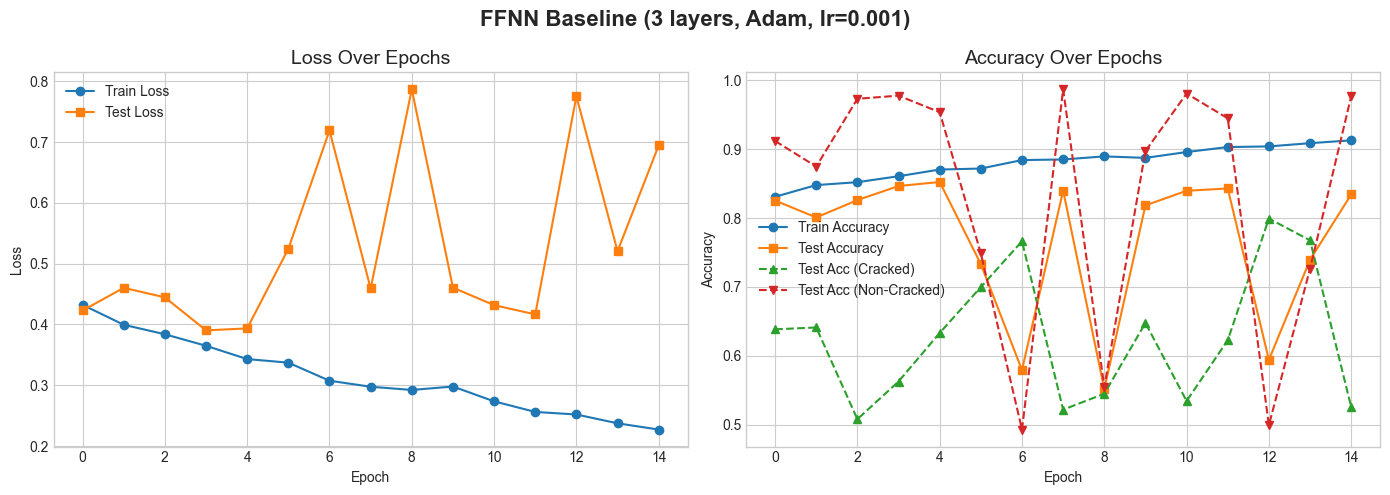

In [13]:
BATCH_SIZE = 32
NUM_EPOCHS = 15

train_loader = DataLoader(tuned_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(tuned_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = FFNN(input_size=input_size, hidden_sizes=[256, 256, 256], dropout_rate=0.0).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = None

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("Starting baseline training...")

baseline_model, baseline_history, baseline_acc = train_model(
    model, train_loader, test_loader, criterion, optimizer, scheduler,
    NUM_EPOCHS, device, 'ffnn_baseline', verbose=True
)

print(f"\nBest test accuracy: {baseline_acc:.4f}")
plot_history(baseline_history, 'FFNN Baseline (3 layers, Adam, lr=0.001)')

### Experiment 2: Effect of Number of Layers
Compare models with 2, 3, and 4 hidden layers while keeping other hyperparameters fixed. This helps us understand how model depth affects performance.

In [15]:
layer_configs = {
    '2 layers': [256, 256],
    '3 layers': [256, 256, 256],
    '4 layers': [256, 256, 256, 256]
}

layer_results = {}

for name, hidden_sizes in layer_configs.items():
    print(f"\n{'='*50}")
    print(f"Training with {name}")
    print(f"{'='*50}")
    
    model = FFNN(input_size=input_size, hidden_sizes=hidden_sizes, dropout_rate=0.0).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    _, history, best_acc = train_model(
        model, train_loader, test_loader, criterion, optimizer, None,
        NUM_EPOCHS, device, f'ffnn_{name}' , verbose=True
    )
    layer_results[name] = {'best_acc': best_acc, 'history': history}
    print(f"Best accuracy for {name}: {best_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, result in layer_results.items():
    ax.plot(result['history']['test_acc'], label=f'{name} (test)', marker='o')
ax.set_title('Effect of Number of Layers on Test Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True)
plt.show()


Training with 2 layers
Epoch [1/15]


Epoch [1/15] LR: 0.001000 | Train Loss: 0.4369 Acc: 0.8299 | Test Loss: 0.4680 Acc: 0.8162
Epoch [2/15]


Epoch [2/15] LR: 0.001000 | Train Loss: 0.4122 Acc: 0.8461 | Test Loss: 0.4084 Acc: 0.8410
Epoch [3/15]


Epoch [3/15] LR: 0.001000 | Train Loss: 0.3970 Acc: 0.8513 | Test Loss: 0.3978 Acc: 0.8516
Epoch [4/15]


Epoch [4/15] LR: 0.001000 | Train Loss: 0.3741 Acc: 0.8586 | Test Loss: 0.3973 Acc: 0.8443
Epoch [5/15]


...

Epoch [8/15] LR: 0.001000 | Train Loss: 0.3191 Acc: 0.8799 | Test Loss: 0.5568 Acc: 0.7136
Epoch [9/15]


Epoch [9/15] LR: 0.001000 | Train Loss: 0.3061 Acc: 0.8844 | Test Loss: 1.0531 Acc: 0.5112
Epoch [10/15]


Epoch [10/15] LR: 0.001000 | Train Loss: 0.2852 Acc: 0.8920 | Test Loss: 0.5369 Acc: 0.7275
Epoch [11/15]


Epoch [11/15] LR: 0.001000 | Train Loss: 0.2809 Acc: 0.8930 | Test Loss: 0.5600 Acc: 0.8372
Epoch [12/15]


KeyboardInterrupt: 

### Experiment 3: Effect of Dropout Rate
Test dropout rates of 0.0, 0.3, and 0.5 on the 3-layer model. Dropout helps prevent overfitting by randomly deactivating neurons during training.

In [ ]:
dropout_rates = [0.0, 0.3, 0.5]
dropout_results = {}

for rate in dropout_rates:
    print(f"\n{'='*50}")
    print(f"Training with dropout={rate}")
    print(f"{'='*50}")
    
    model = FFNN(input_size=input_size, hidden_sizes=[256, 256, 256], dropout_rate=rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    _, history, best_acc = train_model(
        model, train_loader, test_loader, criterion, optimizer, None,
        NUM_EPOCHS, device, f'ffnn_dropout_{rate}' , verbose=True
    )
    dropout_results[f'dropout={rate}'] = {'best_acc': best_acc, 'history': history}
    print(f"Best accuracy with dropout={rate}: {best_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, result in dropout_results.items():
    ax.plot(result['history']['test_acc'], label=f'{name} (test)', marker='o')
ax.set_title('Effect of Dropout Rate on Test Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True)
plt.show()

### Experiment 4: Effect of Optimizer
Compare SGD, Adam, and RMSProp optimizers. Different optimizers use different strategies for updating weights during training.

In [ ]:
optimizers_config = {
    'SGD': lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    'Adam': lambda params: optim.Adam(params, lr=0.001),
    'RMSProp': lambda params: optim.RMSprop(params, lr=0.001)
}

optimizer_results = {}

for name, opt_fn in optimizers_config.items():
    print(f"\n{'='*50}")
    print(f"Training with {name} optimizer")
    print(f"{'='*50}")
    
    model = FFNN(input_size=input_size, hidden_sizes=[256, 256, 256], dropout_rate=0.3).to(device)
    optimizer = opt_fn(model.parameters())
    
    _, history, best_acc = train_model(
        model, train_loader, test_loader, criterion, optimizer, None,
        NUM_EPOCHS, device, f'ffnn_{name}' , verbose=True
    )
    optimizer_results[name] = {'best_acc': best_acc, 'history': history}
    print(f"Best accuracy with {name}: {best_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, result in optimizer_results.items():
    ax.plot(result['history']['test_acc'], label=f'{name} (test)', marker='o')
ax.set_title('Effect of Optimizer on Test Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True)
plt.show()

### Experiment 5: Effect of L2 Regularization (Weight Decay)
Test L2 regularization with weight decay values of 0.0, 1e-4, and 1e-3. L2 regularization penalizes large weights to reduce overfitting.

In [ ]:
weight_decays = [0.0, 1e-4, 1e-3]
wd_results = {}

for wd in weight_decays:
    print(f"\n{'='*50}")
    print(f"Training with weight_decay={wd}")
    print(f"{'='*50}")
    
    model = FFNN(input_size=input_size, hidden_sizes=[256, 256, 256], dropout_rate=0.3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)
    
    _, history, best_acc = train_model(
        model, train_loader, test_loader, criterion, optimizer, None,
        NUM_EPOCHS, device, f'ffnn_wd_{wd}' , verbose=True
    )
    wd_results[f'wd={wd}'] = {'best_acc': best_acc, 'history': history}
    print(f"Best accuracy with wd={wd}: {best_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, result in wd_results.items():
    ax.plot(result['history']['test_acc'], label=f'{name} (test)', marker='o')
ax.set_title('Effect of L2 Regularization on Test Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True)
plt.show()

### Experiment 6: Effect of Learning Rate
Compare learning rates of 0.1, 0.01, and 0.001. The learning rate controls how large steps we take during gradient descent.

In [ ]:
learning_rates = [0.1, 0.01, 0.001]
lr_results = {}

for lr in learning_rates:
    print(f"\n{'='*50}")
    print(f"Training with lr={lr}")
    print(f"{'='*50}")
    
    model = FFNN(input_size=input_size, hidden_sizes=[256, 256, 256], dropout_rate=0.3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    
    _, history, best_acc = train_model(
        model, train_loader, test_loader, criterion, optimizer, None,
        NUM_EPOCHS, device, f'ffnn_lr_{lr}' , verbose=True
    )
    lr_results[f'lr={lr}'] = {'best_acc': best_acc, 'history': history}
    print(f"Best accuracy with lr={lr}: {best_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, result in lr_results.items():
    ax.plot(result['history']['test_acc'], label=f'{name} (test)', marker='o')
ax.set_title('Effect of Learning Rate on Test Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True)
plt.show()

### Experiment 7: Learning Rate Schedulers
Compare StepLR (reduces LR by factor every N epochs) and ReduceLROnPlateau (reduces LR when loss stops improving). Schedulers help fine-tune the model in later epochs.

In [ ]:
scheduler_configs = {
    'No Scheduler': None,
    'StepLR': lambda opt: optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5),
    'ReduceLROnPlateau': lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)
}

scheduler_results = {}

for name, sched_fn in scheduler_configs.items():
    print(f"\n{'='*50}")
    print(f"Training with {name}")
    print(f"{'='*50}")
    
    model = FFNN(input_size=input_size, hidden_sizes=[256, 256, 256], dropout_rate=0.3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = sched_fn(optimizer) if sched_fn else None
    
    _, history, best_acc = train_model(
        model, train_loader, test_loader, criterion, optimizer, scheduler,
        NUM_EPOCHS, device, f'ffnn_sched_{name}' , verbose=True
    )
    scheduler_results[name] = {'best_acc': best_acc, 'history': history}
    print(f"Best accuracy with {name}: {best_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, result in scheduler_results.items():
    ax.plot(result['history']['test_acc'], label=f'{name} (test)', marker='o')
ax.set_title('Effect of Learning Rate Scheduler on Test Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True)
plt.show()

### Experiment 8: Effect of Batch Size
Compare batch sizes of 16, 32, and 64. Batch size affects training speed, memory usage, and the noise in gradient estimates.

In [ ]:
batch_sizes = [16, 32, 64]
bs_results = {}

for bs in batch_sizes:
    print(f"\n{'='*50}")
    print(f"Training with batch_size={bs}")
    print(f"{'='*50}")
    
    train_loader_exp = DataLoader(tuned_train_dataset, batch_size=bs, shuffle=True, num_workers=0)
    test_loader_exp = DataLoader(tuned_test_dataset, batch_size=bs, shuffle=False, num_workers=0)
    
    model = FFNN(input_size=input_size, hidden_sizes=[256, 256, 256], dropout_rate=0.3).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    _, history, best_acc = train_model(
        model, train_loader_exp, test_loader_exp, criterion, optimizer, scheduler,
        NUM_EPOCHS, device, f'ffnn_bs_{bs}' , verbose=True
    )
    bs_results[f'bs={bs}'] = {'best_acc': best_acc, 'history': history}
    print(f"Best accuracy with batch_size={bs}: {best_acc:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name, result in bs_results.items():
    ax.plot(result['history']['test_acc'], label=f'{name} (test)', marker='o')
ax.set_title('Effect of Batch Size on Test Accuracy', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.legend()
ax.grid(True)
plt.show()

### Final Model: Best Configuration
Train the final model using the best hyperparameters found from all experiments above.

In [ ]:
BEST_CONFIG = {
    'hidden_sizes': [256, 256, 256],
    'dropout_rate': 0.3,
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'weight_decay': 1e-4,
    'batch_size': 32,
    'scheduler': 'StepLR',
    'num_epochs': 20
}

print("Training final FFNN model with best configuration:")
for k, v in BEST_CONFIG.items():
    print(f"  {k}: {v}")

train_loader_final = DataLoader(train_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=True, num_workers=0)
test_loader_final = DataLoader(test_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=False, num_workers=0)

final_model = FFNN(
    input_size=input_size,
    hidden_sizes=BEST_CONFIG['hidden_sizes'],
    dropout_rate=BEST_CONFIG['dropout_rate']
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(final_model.parameters(), lr=BEST_CONFIG['learning_rate'], 
                       weight_decay=BEST_CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

final_model, final_history, final_acc = train_model(
    final_model, train_loader_final, test_loader_final, criterion, optimizer, scheduler,
    BEST_CONFIG['num_epochs'], device, 'ffnn_final'
)

torch.save(final_model.state_dict(), 'ffnn_best_model.pth')
print(f"\nFinal model saved. Best test accuracy: {final_acc:.4f}")
plot_history(final_history, 'FFNN Final Model (Best Configuration)')

### Comprehensive Results Summary
Compile all experimental results into a summary table for comparison.

In [ ]:
results_summary = []

results_summary.append({'Experiment': 'Baseline', 'Config': '3 layers, Adam, lr=0.001', 'Best Acc': f"{baseline_acc:.4f}"})

for name, result in layer_results.items():
    results_summary.append({'Experiment': 'Layers', 'Config': name, 'Best Acc': f"{result['best_acc']:.4f}"})

for name, result in dropout_results.items():
    results_summary.append({'Experiment': 'Dropout', 'Config': name, 'Best Acc': f"{result['best_acc']:.4f}"})

for name, result in optimizer_results.items():
    results_summary.append({'Experiment': 'Optimizer', 'Config': name, 'Best Acc': f"{result['best_acc']:.4f}"})

for name, result in wd_results.items():
    results_summary.append({'Experiment': 'Weight Decay', 'Config': name, 'Best Acc': f"{result['best_acc']:.4f}"})

for name, result in lr_results.items():
    results_summary.append({'Experiment': 'Learning Rate', 'Config': name, 'Best Acc': f"{result['best_acc']:.4f}"})

for name, result in scheduler_results.items():
    results_summary.append({'Experiment': 'Scheduler', 'Config': name, 'Best Acc': f"{result['best_acc']:.4f}"})

for name, result in bs_results.items():
    results_summary.append({'Experiment': 'Batch Size', 'Config': name, 'Best Acc': f"{result['best_acc']:.4f}"})

results_summary.append({'Experiment': 'Final', 'Config': 'Best combined config', 'Best Acc': f"{final_acc:.4f}"})

df_results = pd.DataFrame(results_summary)
print(df_results.to_string(index=False))

### Final Evaluation on Train and Test Sets
Run the final evaluation function on both training and test sets to report the model's performance.

In [ ]:
print("="*60)
print("FINAL FFNN MODEL EVALUATION")
print("="*60)

train_loss, train_acc, train_class_acc = evaluate(final_model, train_loader_final, criterion, device)
test_loss, test_acc, test_class_acc = evaluate(final_model, test_loader_final, criterion, device)

print(f"\nTraining Set:")
print(f"  Loss: {train_loss:.4f}")
print(f"  Accuracy: {train_acc:.4f}")
print(f"  Cracked Accuracy: {train_class_acc[1]:.4f}")
print(f"  Non-Cracked Accuracy: {train_class_acc[0]:.4f}")

print(f"\nTest Set:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Cracked Accuracy: {test_class_acc[1]:.4f}")
print(f"  Non-Cracked Accuracy: {test_class_acc[0]:.4f}")

gap = train_acc - test_acc
print(f"\nTrain-Test Gap: {gap:.4f} {'(Overfitting)' if gap > 0.05 else '(Good generalization)'}")